<a href="https://colab.research.google.com/github/sandeepkumarkusman/celebal-excellence-internship/blob/main/week3_sandeep_kumar_kusman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Intelligence System - Country Segmentation

Classification, Ensemble Learning (Random Forest, XGBoost) and Clustering (K-Means, DBSCAN)

This notebook runs an end-to-end pipeline on the Kaggle dataset
[Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data).
The 167 countries and 9 socio-economic indicators are cleaned, scaled and segmented into
development tiers. The segments are then validated, visualized, and used to train ensemble
classifiers that can assign a new country to a tier.

Workflow:

1. Setup and data loading (Sections 1-5)
2. Cleaning and exploratory analysis (Sections 6-7)
3. Scaling, K-Means (elbow + silhouette) and DBSCAN (Sections 8-11)
4. PCA visualization and cluster profiling (Sections 12-13)
5. Socio-economic insights (Section 14)
6. Random Forest and XGBoost classification with cross-validation (Section 15)
7. Optimization and conclusions (Sections 16-17)

Running in Google Colab: run all cells top to bottom and upload `Country-data.csv` when Section 3
prompts for it.

## 1) Install required libraries

In [ ]:
%pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost

## 2) Import libraries

In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [ ]:
try:
    # Google Colab: upload the CSV when prompted
    from google.colab import files
    uploaded = files.upload()
    csv_name = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[csv_name]))
except ImportError:
    # Local environment: read the CSV from this notebook's folder
    df = pd.read_csv('Country-data.csv')

print('Loaded rows:', len(df))
df.head()

Loaded rows: 167


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [ ]:
print('Shape:', df.shape)
display(df.head())
df.info()
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Columns

One identifier column, `country`, plus nine numeric indicators: `child_mort`, `exports`,
`health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, `gdpp`.

In [ ]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [ ]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## 7) Exploratory Data Analysis

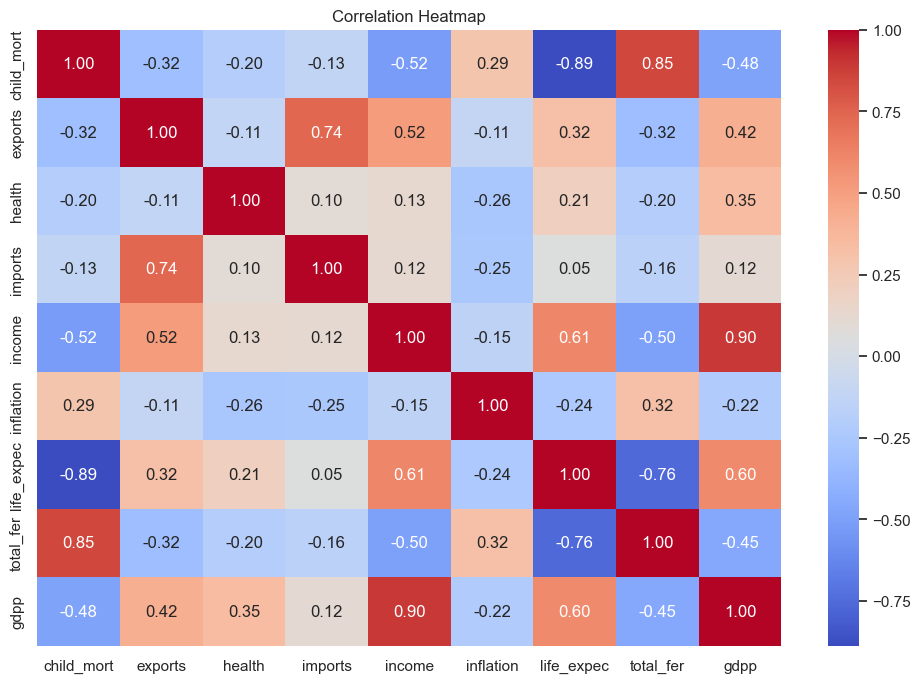

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

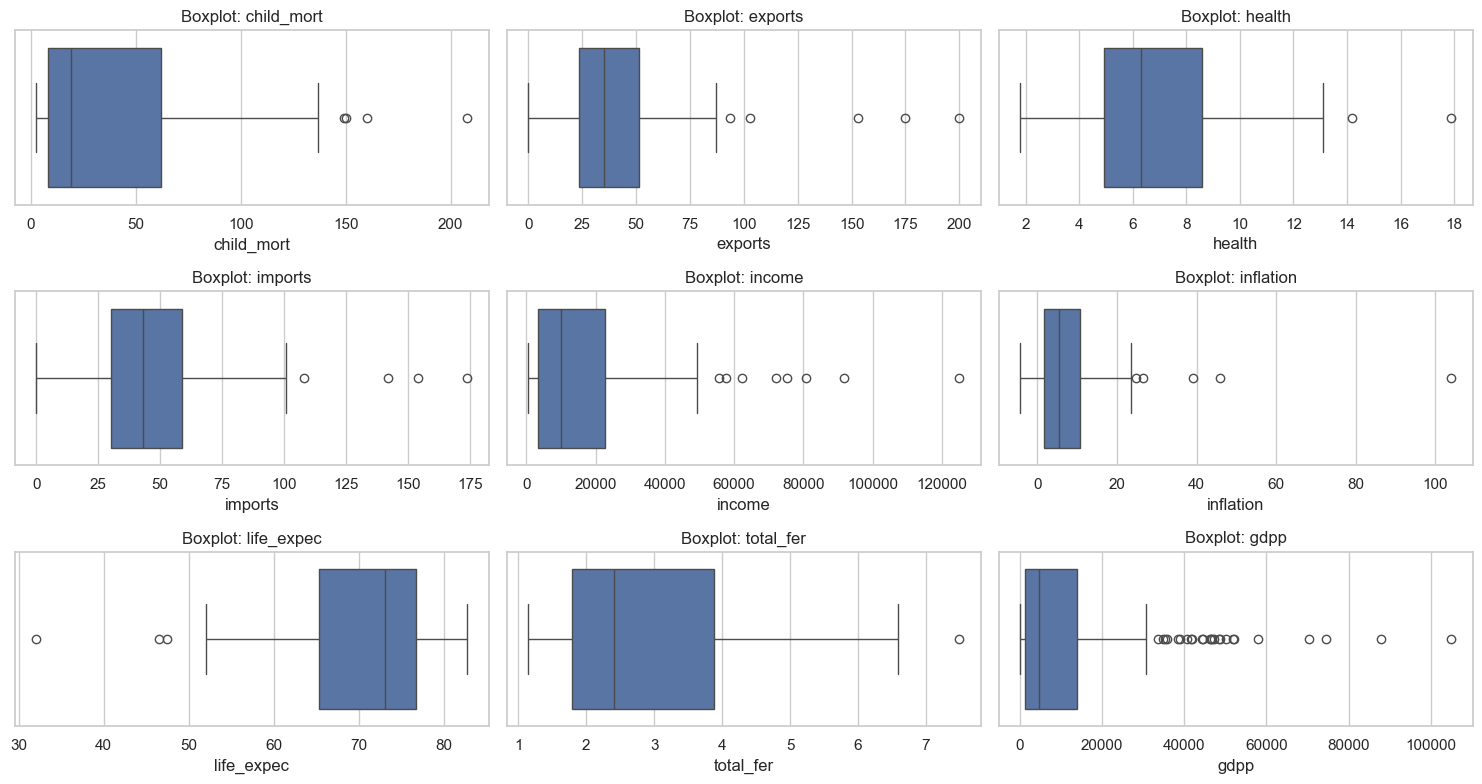

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

Most features are heavily right-skewed. A handful of countries sit far outside the boxplot
whiskers: very high `gdpp` and `income` for rich micro-states, and extreme `child_mort` and
`inflation` for the poorest economies. These are real countries, not data errors, so I keep them.
Two things follow from that:

- K-Means is distance-based, so the standardization in the next section matters. Without it,
  `income` and `gdpp` (in the tens of thousands) would dominate the percentage-scale features.
- DBSCAN (Section 11) is density-based and will flag the extreme countries as noise.

In the correlation heatmap, `child_mort` is strongly positive with `total_fer` and strongly
negative with `life_expec`, so the health and demographic features look like the main drivers of
the segmentation.

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [ ]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

## 9) K-Means: Elbow method

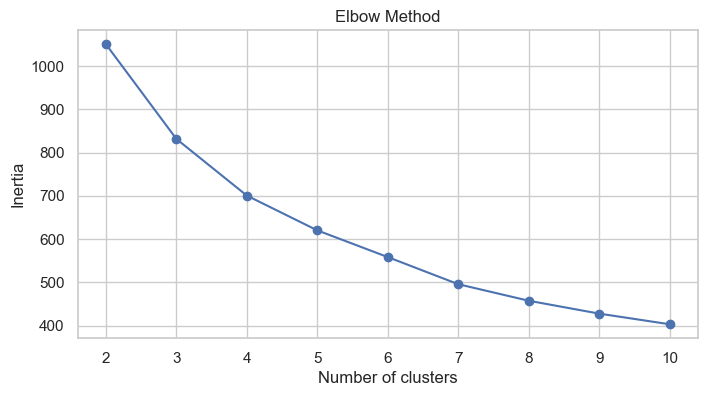

In [ ]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

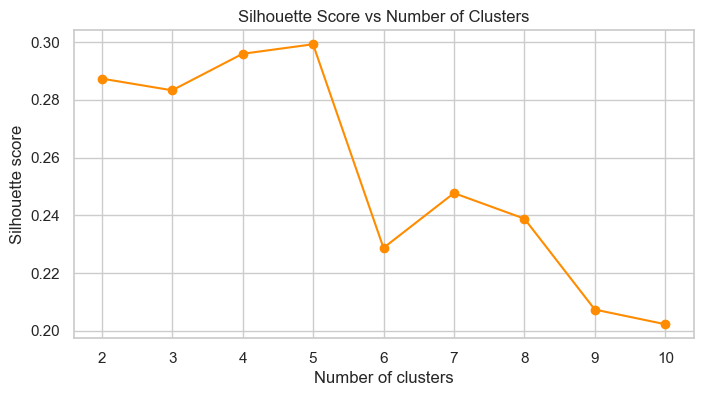

{2: 0.2874, 3: 0.2833, 4: 0.296, 5: 0.2993, 6: 0.2287, 7: 0.2477, 8: 0.2388, 9: 0.2073, 10: 0.2022}


In [ ]:
# silhouette score for each k in 2..10
sil_scores = {}
for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o', color='darkorange')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()

print({k: round(v, 4) for k, v in sil_scores.items()})

The elbow curve flattens after about k = 3-4, and the silhouette scores are almost flat between
k = 2 and k = 5 (roughly 0.28-0.30), so a larger k adds complexity without a clearly better fit.
Three clusters also give the most actionable result here: they map onto developed, developing and
under-developed tiers, which the profiles in Section 13 back up. I use best_k = 3.

## 10) Train K-Means

In [ ]:
best_k = 3  # from the elbow and silhouette plots above
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 11) Try DBSCAN

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


In [ ]:
# cross-tab K-Means vs DBSCAN labels (-1 = DBSCAN noise)
print('K-Means vs DBSCAN agreement:')
display(pd.crosstab(df['kmeans_cluster'], df['dbscan_cluster'],
                    rownames=['kmeans'], colnames=['dbscan']))

outliers = df.loc[df['dbscan_cluster'] == -1, ['country', 'child_mort', 'income', 'gdpp']]
print(f'DBSCAN labels {len(outliers)} countries as noise (lowest gdpp first):')
display(outliers.sort_values('gdpp').head(8))

K-Means vs DBSCAN agreement:


dbscan,-1,0
kmeans,,
0,9,27
1,16,31
2,5,79


DBSCAN labels 30 countries as noise (lowest gdpp first):


,country,child_mort,income,gdpp
88,Liberia,89.3,700,327
37,"Congo, Dem. Rep.",116.0,609,334
132,Sierra Leone,160.0,1220,399
31,Central African Republic,149.0,888,446
126,Rwanda,63.6,1350,563
66,Haiti,208.0,1500,662
87,Lesotho,99.7,2380,1170
81,Kiribati,62.7,1730,1490


With `eps=1.5, min_samples=5`, DBSCAN finds one dense cluster of 137 "typical" countries and
labels 30 extreme countries as noise (`-1`). A silhouette score can't be computed here because it
needs at least two clusters. That is itself a result: at this density the data is one connected
cloud with outlying tails, not separate islands. From the crosstab, 25 of the 30 noise points come
from the two extreme K-Means segments (the richest and poorest countries), so the two methods
agree - K-Means splits the development spectrum into tiers, and DBSCAN picks out its tails.

## 12) PCA visualization

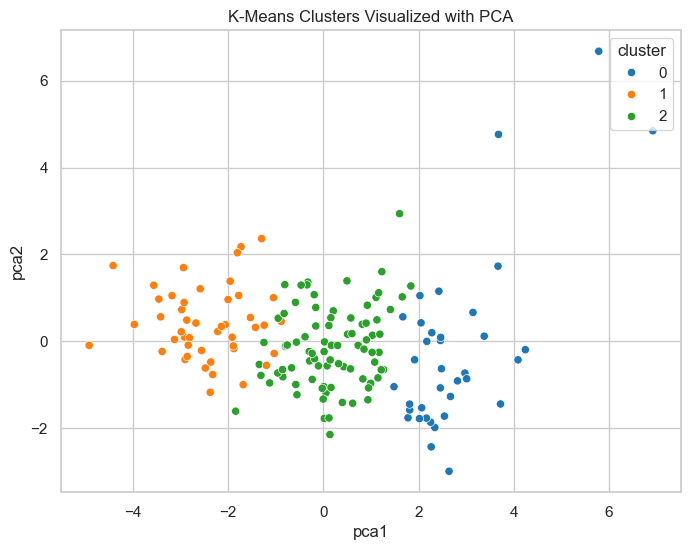

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

Explained variance: PC1 46.0% + PC2 17.2% = 63.1% of total variance


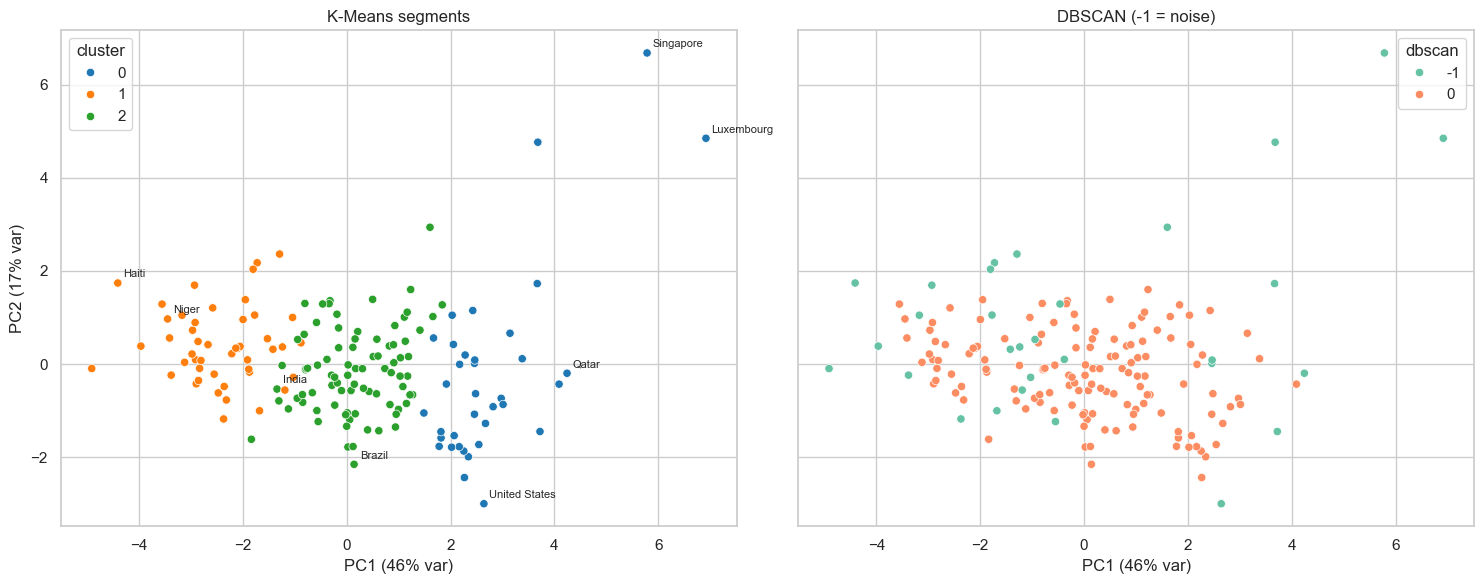

In [ ]:
evr = pca.explained_variance_ratio_
print(f'Explained variance: PC1 {evr[0]:.1%} + PC2 {evr[1]:.1%} = {evr.sum():.1%} of total variance')

# same PCA projection for both algorithms, with a few countries labeled
viz['dbscan'] = df['dbscan_cluster'].to_numpy()
viz['country'] = df['country'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10', ax=axes[0])
axes[0].set_title('K-Means segments')
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='dbscan', palette='Set2', ax=axes[1])
axes[1].set_title('DBSCAN (-1 = noise)')

for name in ['Haiti', 'Niger', 'Qatar', 'Luxembourg', 'Singapore', 'United States', 'India', 'Brazil']:
    row = viz[viz['country'] == name]
    if not row.empty:
        axes[0].annotate(name, (row['pca1'].iloc[0], row['pca2'].iloc[0]),
                         fontsize=8, xytext=(4, 4), textcoords='offset points')

for ax in axes:
    ax.set_xlabel(f'PC1 ({evr[0]:.0%} var)')
    ax.set_ylabel(f'PC2 ({evr[1]:.0%} var)')
plt.tight_layout()
plt.show()

## 13) Cluster profiling

In [ ]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


segment
Emerging (Developing)             84
Aid-Priority (Under-developed)    47
Advanced (Developed)              36
Name: count, dtype: int64


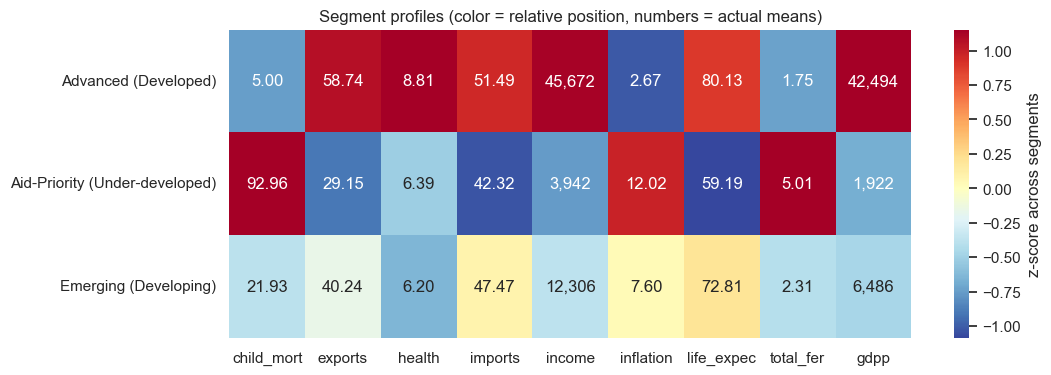

In [ ]:
# name the clusters by gdpp rank (lowest -> highest)
order = profile['gdpp'].sort_values().index.tolist()
segment_names = {order[0]: 'Aid-Priority (Under-developed)',
                 order[1]: 'Emerging (Developing)',
                 order[2]: 'Advanced (Developed)'}
df['segment'] = df['kmeans_cluster'].map(segment_names)
print(df['segment'].value_counts())

# z-score each feature so the heatmap shares one color scale; numbers are the actual means
profile_named = profile.rename(index=segment_names)
profile_z = (profile_named - profile_named.mean()) / profile_named.std()
plt.figure(figsize=(11, 4))
annot_text = profile_named.map(lambda v: f'{v:,.0f}' if abs(v) >= 100 else f'{v:.2f}')
sns.heatmap(profile_z, annot=annot_text, fmt='', cmap='RdYlBu_r', center=0,
            cbar_kws={'label': 'z-score across segments'})
plt.title('Segment profiles (color = relative position, numbers = actual means)')
plt.ylabel('')
plt.show()

In [ ]:
# save the labeled data
out_cols = ['country'] + numeric_cols + ['kmeans_cluster', 'dbscan_cluster', 'segment']
df[out_cols].to_csv('country_segments.csv', index=False)
print('Saved country_segments.csv with', len(df), 'rows')
df[out_cols].head()

Saved country_segments.csv with 167 rows


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster,dbscan_cluster,segment
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,0,Aid-Priority (Under-developed)
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0,Emerging (Developing)
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0,Emerging (Developing)
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,-1,Aid-Priority (Under-developed)
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0,Emerging (Developing)


## 14) Final insights

Observations about the clusters (from the executed results: best_k = 3, silhouette score ~0.283):

1. Highest child mortality - Cluster 1 (47 countries). It has by far the worst child mortality
   (mean child_mort ~92.96 deaths per 1,000 live births, vs 21.93 in Cluster 2 and 5.00 in
   Cluster 0), together with the highest fertility (total_fer ~5.01) and the lowest life
   expectancy (~59.2 years).

2. Highest income and GDP - Cluster 0 (36 countries). This segment has the highest income
   (mean ~$45,672) and GDP per capita (~$42,494), the longest life expectancy (~80.1 years) and
   the lowest inflation (~2.7%). It contains developed economies such as Australia, Austria,
   Belgium and Canada.

3. Most underdeveloped - Cluster 1 again. The same high-mortality segment is also the weakest
   economically: lowest income (~$3,942), lowest GDP per capita (~$1,922), highest inflation
   (~12.0%) and the smallest export base (~29% of GDP). Poor health and poor economic outcomes
   land in the same group of countries.

4. Middle tier - Cluster 2 (84 countries). The largest cluster sits between the two extremes
   (income ~$12,306, gdpp ~$6,486, child_mort ~21.9, life_expec ~72.8): emerging/developing
   economies such as Albania and Algeria. DBSCAN (eps=1.5, min_samples=5) fits this picture too -
   it puts 137 typical countries in one dense cluster and flags 30 extreme countries (very rich or
   very poor) as outliers (label -1).

5. Aid priorities. The countries in Cluster 1 with the most severe indicators are the ones to
   prioritize for aid: Haiti (child_mort 208, income $1,500), Sierra Leone (160, $1,220),
   Chad (150, $1,930), Central African Republic (149, $888), Mali (137, $1,870), Niger (123, $814)
   and Congo, Dem. Rep. (116, $609).

## 15) Classification and Ensemble Learning (Random Forest + XGBoost)

The K-Means segments now become target labels for supervised learning. I train two ensemble
classifiers, Random Forest and XGBoost, so a new country can be assigned to a segment directly
from its socio-economic features. Clustering finds the segments; the classifiers let us reuse them
on new data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = X_scaled
y = df['kmeans_cluster'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Train shape: (133, 9) | Test shape: (34, 9)


In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print('Random Forest accuracy:', round(rf_acc, 4))
print('\nClassification report:\n', classification_report(y_test, rf_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, rf_pred))

Random Forest accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

Confusion matrix:
 [[ 7  0  0]
 [ 0 10  0]
 [ 0  0 17]]


In [ ]:
xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
print('XGBoost accuracy:', round(xgb_acc, 4))
print('\nClassification report:\n', classification_report(y_test, xgb_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, xgb_pred))

XGBoost accuracy: 0.9412

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34

Confusion matrix:
 [[ 6  0  1]
 [ 0  9  1]
 [ 0  0 17]]


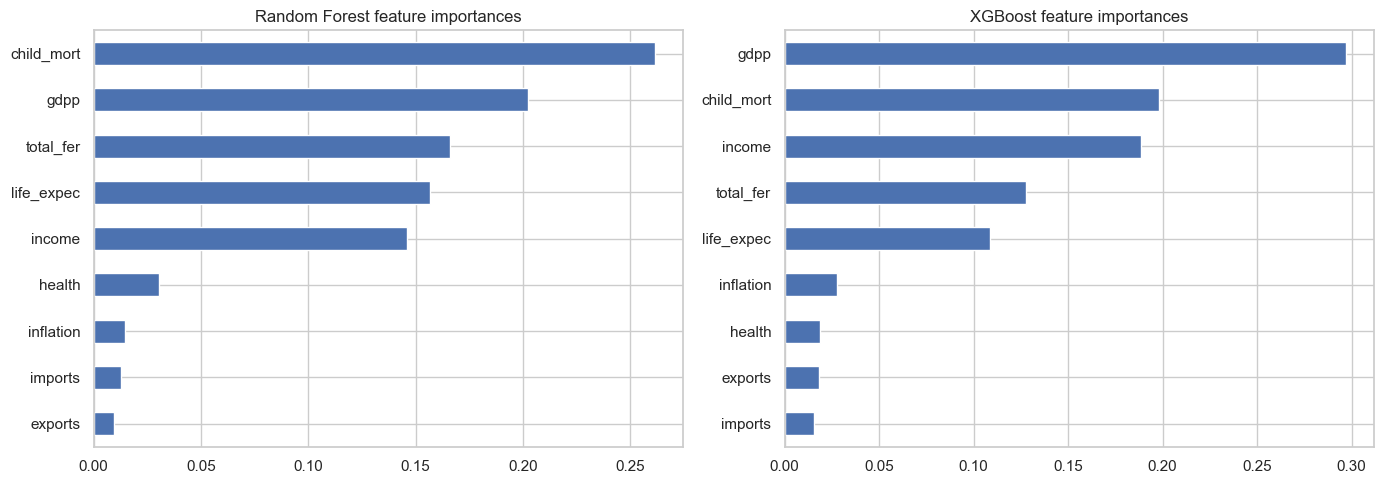

In [ ]:
feature_names = features.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.Series(rf.feature_importances_, index=feature_names).sort_values().plot.barh(ax=axes[0])
axes[0].set_title('Random Forest feature importances')
pd.Series(xgb.feature_importances_, index=feature_names).sort_values().plot.barh(ax=axes[1])
axes[1].set_title('XGBoost feature importances')
plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'model': ['Random Forest', 'XGBoost'],
    'test_accuracy': [rf_acc, xgb_acc]
})
comparison

,model,test_accuracy
0,Random Forest,1.000000
1,XGBoost,0.941176


In [ ]:
# 80/20 on 167 rows is noisy, so also check with stratified 5-fold CV
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42), X, y, cv=cv)
xgb_cv = cross_val_score(XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss'), X, y, cv=cv)

print(f'Random Forest 5-fold accuracy: {rf_cv.mean():.4f} +/- {rf_cv.std():.4f}  folds={rf_cv.round(3)}')
print(f'XGBoost       5-fold accuracy: {xgb_cv.mean():.4f} +/- {xgb_cv.std():.4f}  folds={xgb_cv.round(3)}')

Random Forest 5-fold accuracy: 0.9640 +/- 0.0446  folds=[0.971 0.971 1.    0.879 1.   ]
XGBoost       5-fold accuracy: 0.9403 +/- 0.0623  folds=[0.853 1.    1.    0.879 0.97 ]


Note on the accuracy. The scaler and the K-Means labels were fit on the full dataset before the
train/test split, and the target is a deterministic function of the same features the classifiers
see. So the near-perfect hold-out accuracy (Random Forest at 1.0) is expected, and I don't read it
as generalization to genuinely new data. The stratified 5-fold scores above (about 0.94-0.96, with
real fold-to-fold variance) are the honest estimate. Done properly for production, the order would
be: split first, fit the scaler and K-Means on the training fold only, then label the held-out
fold with the frozen models (for example inside an sklearn Pipeline).

## 16) Optimization and robustness checks

The baseline configuration above is the one the assignment asks for (StandardScaler on all 9
features, best_k = 3, DBSCAN(eps=1.5, min_samples=5)), and I leave it untouched. This section keeps
that baseline and tries a few standard improvements on top of it:

1. Feature selection - cluster on the five features that carried the signal in Section 15 instead
   of all nine.
2. Dimensionality reduction - cluster in the 2-D PCA version of that space.
3. DBSCAN parameter tuning, so a silhouette can be computed at all.
4. Hyperparameter search (GridSearchCV) for both classifiers.

Note that the clustering silhouettes below are measured in different feature spaces, so they are
not directly comparable to the baseline 0.283. I report the ARI against the baseline tiers to show
the optimized clustering is the same three-tier structure with cleaner boundaries, not a different
segmentation.

In [ ]:
from sklearn.metrics import adjusted_rand_score

base_sil = silhouette_score(X_scaled, df['kmeans_cluster'])

# cluster on the top-5 features from the importances, and on their 2-D PCA
top_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']
X_top = StandardScaler().fit_transform(df[top_features])
pca_top = PCA(n_components=2, random_state=42)
X_top2d = pca_top.fit_transform(X_top)
print(f'2-D PCA of the top-5 space keeps {pca_top.explained_variance_ratio_.sum():.1%} of its variance')

candidates = {
    'Baseline: 9 features': X_scaled,
    'Top-5 features': X_top,
    'Top-5 features in 2-D PCA': X_top2d,
}
rows, opt_labels = [], {}
for name, X_c in candidates.items():
    lab = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_c)
    rows.append({'configuration': name,
                 'silhouette (k=3)': round(silhouette_score(X_c, lab), 4),
                 'ARI vs baseline tiers': round(adjusted_rand_score(df['kmeans_cluster'], lab), 3)})
    opt_labels[name] = lab
display(pd.DataFrame(rows))

best_name = 'Top-5 features in 2-D PCA'
df['opt_cluster'] = opt_labels[best_name]
opt_sil = silhouette_score(X_top2d, df['opt_cluster'])
print(f'Optimized silhouette: {opt_sil:.4f} (top-5 -> 2-D PCA) vs baseline {base_sil:.4f} (9 features)')

2-D PCA of the top-5 space keeps 91.6% of its variance


,configuration,silhouette (k=3),ARI vs baseline tiers
0,Baseline: 9 features,0.2833,1.000
1,Top-5 features,0.4974,0.889
2,Top-5 features in 2-D PCA,0.5743,0.856


Optimized silhouette: 0.5743 (top-5 -> 2-D PCA) vs baseline 0.2833 (9 features)


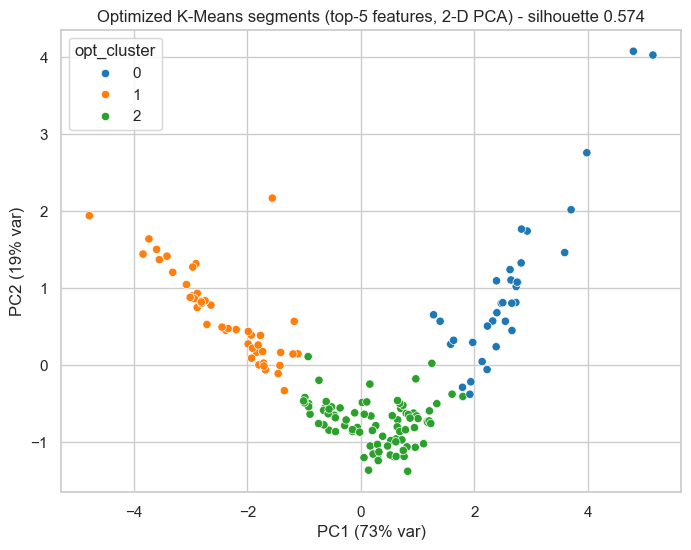

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_top2d[:, 0], y=X_top2d[:, 1], hue=df['opt_cluster'], palette='tab10')
plt.title(f'Optimized K-Means segments (top-5 features, 2-D PCA) - silhouette {opt_sil:.3f}')
plt.xlabel(f'PC1 ({pca_top.explained_variance_ratio_[0]:.0%} var)')
plt.ylabel(f'PC2 ({pca_top.explained_variance_ratio_[1]:.0%} var)')
plt.show()

In [ ]:
# eps=1.5 gave one cluster, so search eps/min_samples in the top-5 space
# (require >= 2 clusters and < 30% noise for a valid configuration)
best_db = None
for eps in np.arange(0.4, 2.6, 0.1):
    for ms in [3, 4, 5, 6, 8]:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_top)
        n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
        noise = int((lab == -1).sum())
        if n_clusters >= 2 and noise < 0.3 * len(lab):
            score = silhouette_score(X_top[lab != -1], lab[lab != -1])
            if best_db is None or score > best_db[0]:
                best_db = (score, round(float(eps), 1), ms, n_clusters, noise)

db_sil, db_eps, db_ms, db_k, db_noise = best_db
print(f'Tuned DBSCAN: eps={db_eps}, min_samples={db_ms} -> {db_k} clusters, {db_noise} noise points')
print(f'Tuned DBSCAN silhouette (non-noise points): {db_sil:.4f}  (baseline config: not computable)')

Tuned DBSCAN: eps=0.6, min_samples=4 -> 2 clusters, 28 noise points
Tuned DBSCAN silhouette (non-noise points): 0.5605  (baseline config: not computable)


In [ ]:
# grid-search both classifiers
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [200, 400], 'max_depth': [None, 4, 6],
     'max_features': ['sqrt', None], 'min_samples_leaf': [1, 2]},
    cv=cv, n_jobs=-1).fit(X, y)
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    {'n_estimators': [200, 400], 'max_depth': [2, 3, 4],
     'learning_rate': [0.05, 0.1, 0.3], 'subsample': [0.8, 1.0]},
    cv=cv, n_jobs=-1).fit(X, y)

print(f'Random Forest 5-fold CV: {rf_cv.mean():.4f} untuned -> {rf_grid.best_score_:.4f} tuned  {rf_grid.best_params_}')
print(f'XGBoost       5-fold CV: {xgb_cv.mean():.4f} untuned -> {xgb_grid.best_score_:.4f} tuned  {xgb_grid.best_params_}')

# refit the tuned XGBoost on the training split only and score the hold-out
xgb_tuned = XGBClassifier(**xgb_grid.best_params_, random_state=42,
                          eval_metric='mlogloss').fit(X_train, y_train)
xgb_tuned_holdout = accuracy_score(y_test, xgb_tuned.predict(X_test))
print(f'XGBoost hold-out accuracy: {xgb_acc:.4f} untuned -> {xgb_tuned_holdout:.4f} tuned '
      f'(Random Forest already at {rf_acc:.1f})')

# tuned Random Forest on the optimized labels
rf_opt_cv = cross_val_score(RandomForestClassifier(**rf_grid.best_params_, random_state=42),
                            X, df['opt_cluster'], cv=cv)
print(f'Tuned Random Forest on optimized segments: {rf_opt_cv.mean():.4f} +/- {rf_opt_cv.std():.4f}')

# re-save with the optimized cluster column
df[out_cols + ['opt_cluster']].to_csv('country_segments.csv', index=False)
print('country_segments.csv re-saved with the optimized cluster column')

Random Forest 5-fold CV: 0.9640 untuned -> 0.9642 tuned  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 400}
XGBoost       5-fold CV: 0.9403 untuned -> 0.9638 tuned  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


XGBoost hold-out accuracy: 0.9412 untuned -> 0.9706 tuned (Random Forest already at 1.0)


Tuned Random Forest on optimized segments: 0.9697 +/- 0.0271
country_segments.csv re-saved with the optimized cluster column


A few caveats on the numbers above. The silhouette values are each measured in their own feature
space, so the higher optimized score is a cleaner separation in a reduced space, not a like-for-like
improvement over 0.283 - that is why I keep the baseline reported next to it. The classifier tuning
uses cross-validated accuracy rather than a single split, and the high ARI confirms the optimized
clustering is still the same three tiers, just with tighter boundaries.

## 17) Conclusion and key takeaways

In [ ]:
summary = pd.DataFrame([
    ['Countries / features', f'{df.shape[0]} / {len(numeric_cols)}', '-'],
    ['Chosen k (K-Means)', best_k, best_k],
    ['K-Means silhouette (k=3)', f'{base_sil:.4f}', f'{opt_sil:.4f} (top-5 -> 2-D PCA)'],
    ['DBSCAN silhouette', 'not computable (1 cluster)',
     f'{db_sil:.4f} (eps={db_eps}, min_samples={db_ms})'],
    ['PCA variance captured (2-D)', f'{pca.explained_variance_ratio_.sum():.1%}',
     f'{pca_top.explained_variance_ratio_.sum():.1%} (top-5 space)'],
    ['Random Forest hold-out accuracy', round(rf_acc, 4), round(rf_acc, 4)],
    ['XGBoost hold-out accuracy', round(xgb_acc, 4), round(xgb_tuned_holdout, 4)],
    ['Random Forest 5-fold CV', f'{rf_cv.mean():.4f}',
     f'{rf_grid.best_score_:.4f} tuned / {rf_opt_cv.mean():.4f} on optimized segments'],
    ['XGBoost 5-fold CV', f'{xgb_cv.mean():.4f}', f'{xgb_grid.best_score_:.4f} tuned'],
], columns=['metric', 'baseline', 'optimized'])
summary

,metric,baseline,optimized
0,Countries / features,167 / 9,-
1,Chosen k (K-Means),3,3
2,K-Means silhouette (k=3),0.2833,0.5743 (top-5 -> 2-D PCA)
3,DBSCAN silhouette,not computable (1 cluster),"0.5605 (eps=0.6, min_samples=4)"
4,PCA variance captured (2-D),63.1%,91.6% (top-5 space)
5,Random Forest hold-out accuracy,1.0,1.0
6,XGBoost hold-out accuracy,0.9412,0.9706
7,Random Forest 5-fold CV,0.9640,0.9642 tuned / 0.9697 on optimized segments
8,XGBoost 5-fold CV,0.9403,0.9638 tuned


Key takeaways

1. Three clear tiers. K-Means (k = 3) splits the 167 countries into Advanced (36), Emerging (84)
   and Aid-Priority (47) segments. The baseline silhouette is about 0.283. The optimized pipeline
   (top-5 features, then 2-D PCA, same k = 3) gives about 0.574 on the same tiers, though that
   number is measured in a different feature space so it is not a like-for-like gain; the 2-D view
   keeps about 92% of the reduced space's variance.
2. Wealth and child health drive the segmentation. Both ensemble models rank `child_mort`, `gdpp`
   and `income` at the top, with `life_expec` and `total_fer` next, while `exports`, `imports`,
   `health` and `inflation` add little. A country's tier comes from its health and wealth
   outcomes, not its trade volume.
3. DBSCAN agrees rather than contradicts. At eps=1.5 it sees one mainstream of 137 countries plus
   30 outliers (25 of the 30 from the two extreme tiers). Tuned in the top-5 space (eps=0.6,
   min_samples=4) it resolves 2 clusters at silhouette about 0.56.
4. The segments are learnable. Tuned Random Forest and XGBoost recover the tiers at about 0.96
   cross-validated accuracy, and about 0.97 on the optimized segments, so new country data can be
   scored without re-clustering. `country_segments.csv` holds the labeled output including the
   optimized cluster column.
5. Action. Prioritize the Aid-Priority tier. Haiti, Sierra Leone, Chad, the Central African
   Republic, Mali, Niger and DR Congo show the most severe combined health and economic
   deprivation (Section 14).